In [40]:
import pandas as pd
import json
import numpy as np
import seaborn as sns
from sklearn.neighbors import BallTree

from bokeh.plotting import figure ,show,output_notebook

output_notebook()

Loading BokehJS ...

#  ***comptages vehicules cyclistes pietons***

In [42]:
df = pd.read_csv("comptage_velo_2025.csv")
df.sample(10)

,date,heure,id_compteur,nb_passages,longitude,latitude
74884,2025-01-20,11:00:00,300014986,1.0,-73.597117,45.530526
104423,2025-01-28,03:45:00,100004575,0.0,-73.574320,45.527496
111933,2025-01-30,02:30:00,100017441,0.0,-73.575870,45.506134
19892,2025-01-06,03:15:00,100053210,0.0,-73.520435,45.595537
547917,2025-05-29,09:45:00,300028650,13.0,-73.618386,45.547048
198106,2025-02-21,20:15:00,300014986,6.0,-73.597117,45.530526
325703,2025-03-28,22:30:00,300014993,2.0,-73.655034,45.551458
573877,2025-06-05,19:00:00,100001753,28.0,-73.544426,45.530216
242936,2025-03-06,05:00:00,300020817,0.0,-73.616870,45.539050
570091,2025-06-04,17:30:00,100054073,13.0,-73.590636,45.560713


# ***DATASET  MÉTÉO***

In [44]:
# 1. Charger le fichier météo
df_meteo = pd.read_csv("meteo_montreal_horaire.csv")

# Vérifier que les colonnes sont bien lues
print("Colonnes du dataset météo :", df_meteo.columns.tolist())
display(df_meteo.head())  # aperçu

Colonnes du dataset météo : ['date', 'heure', 'temp_c', 'precip_mm', 'wind_kmh', 'humidite_pct', 'cloud_pct']


,date,heure,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
0,2022-01-01,00:00:00,-2.8,0.0,2.1,99,100
1,2022-01-01,01:00:00,-3.7,0.0,2.3,99,100
2,2022-01-01,02:00:00,-2.9,0.0,4.5,98,100
3,2022-01-01,03:00:00,-3.2,0.0,5.1,98,100
4,2022-01-01,04:00:00,-4.1,0.0,5.8,98,100


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775481 entries, 0 to 775480
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         775481 non-null  object 
 1   heure        775481 non-null  object 
 2   id_compteur  775481 non-null  int64  
 3   nb_passages  775477 non-null  float64
 4   longitude    775481 non-null  float64
 5   latitude     775481 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 35.5+ MB


 # ***Drop Colonnes*** 
 -(['id_compteur'])

In [47]:
ColumnToDrop = ['id_compteur']
df = df.drop(columns=ColumnToDrop)
df.head(5)

,date,heure,nb_passages,longitude,latitude
0,2025-01-01,00:00:00,0.0,-73.590636,45.560713
1,2025-01-01,00:00:00,0.0,-73.613370,45.631590
2,2025-01-01,00:00:00,0.0,-73.544410,45.501270
3,2025-01-01,00:00:00,0.0,-73.538818,45.555084
4,2025-01-01,00:00:00,2.0,-73.562970,45.516216


# ***6. AJOUT DU DATASET MÉTÉO***

In [49]:
# 5. Fusion météo avec df_final (celui qu’on a déjà obtenu avec les autres jointures)
# On utilise "date" + "heure" comme clés de jointure
df = df.merge(  df_meteo,
    on=["date", "heure"],  # jointure sur date + heure
    how="left"             # garder toutes les lignes vélo, même si météo manquante
)
print("Jointure vélo: donnée météo terminées")
# 6. Vérifier le résultat
print("Données finales avec météo intégrée :")
df.head()

Jointure vélo: donnée météo terminées
Données finales avec météo intégrée :


,date,heure,nb_passages,longitude,latitude,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
0,2025-01-01,00:00:00,0.0,-73.590636,45.560713,0.9,0.0,10.4,88.0,98.0
1,2025-01-01,00:00:00,0.0,-73.613370,45.631590,0.9,0.0,10.4,88.0,98.0
2,2025-01-01,00:00:00,0.0,-73.544410,45.501270,0.9,0.0,10.4,88.0,98.0
3,2025-01-01,00:00:00,0.0,-73.538818,45.555084,0.9,0.0,10.4,88.0,98.0
4,2025-01-01,00:00:00,2.0,-73.562970,45.516216,0.9,0.0,10.4,88.0,98.0


In [50]:
df.isnull().sum()

date                 0
heure                0
nb_passages          4
longitude            0
latitude             0
temp_c          581609
precip_mm       581609
wind_kmh        581609
humidite_pct    581609
cloud_pct       581609
dtype: int64

# ***Remplissage des données manquante pour les colonnes météo***
 - On remarque que le niveau de granularité du dataset meteo et a l'heure c.a.d les données sont affiché chaque heure,
 
 - alors que le niveau de granularité du csv comptage_velo_2025 et du dataset final est de 15 minutes pres c.a.d dans chaque 15 minutes 
 on a un chargement

Durant la jointure on se trouve avec bcp de null (heure avec : ??:15,??:30, ??45 sont null) juste heure avec ??:00 qui sont renseigné

D'ou il faut trouver un mécanisme de charger les données manquante. 
dans ***Pandas*** il existe une methde qui permet de faire une progression linéaire qui donne une progression entre la valeur précedente et la valeur suivante 

- **df['temp_c'] = df['temp_c'].fillna(method='bfill')  # backward fill**
- **df['temp_c'] = df['temp_c'].fillna(method='ffill')  # forward fill**
- **df['temp_c'] = df['temp_c'].interpolate(method='linear')  # linear fill** 
Interpoler entre les valeurs précédentes et suivantes (moyenne si elles sont équidistantes) ce qu'on a utiliser

In [52]:
# On remarque que le niveau de granularité dataset meteo et a l'heure c.a.d les données sont sont affiché pour chaque heure 
# alors que le niveau de granularité du csv comptage_velo_2025 et du dataset final est de 15 minutes pres c.a.d dans chaque 15 minutes 
# on a un chargement
df['temp_c']       = df['temp_c'].interpolate(method='linear').round(1)
df['precip_mm']    = df['precip_mm'].interpolate(method='linear').round(0)
df['wind_kmh']     = df['wind_kmh'].interpolate(method='linear').round(1)
df['humidite_pct'] = df['humidite_pct'].interpolate(method='linear').round(0)
df['cloud_pct']    = df['cloud_pct'].interpolate(method='linear').round(0)
df.sample(10)

,date,heure,nb_passages,longitude,latitude,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
203988,2025-02-23,10:00:00,0.0,-73.555760,45.553646,-4.3,0.0,13.8,85.0,98.0
522996,2025-05-22,08:15:00,40.0,-73.559602,45.506008,9.3,0.0,14.3,72.0,100.0
769001,2025-07-30,04:00:00,0.0,-73.520435,45.595537,21.0,0.0,4.9,75.0,37.0
506237,2025-05-17,15:15:00,6.0,-73.542387,45.546844,20.5,1.0,10.6,82.0,88.0
45761,2025-01-12,21:00:00,0.0,-73.655034,45.551458,-7.0,0.0,7.2,82.0,100.0
472594,2025-05-08,10:00:00,6.0,-73.656442,45.550894,7.3,0.0,10.2,74.0,100.0
448668,2025-05-01,20:30:00,4.0,-73.559602,45.506008,12.2,0.0,9.0,53.0,100.0
551520,2025-05-30,11:00:00,4.0,-73.544410,45.501270,17.1,0.0,11.7,76.0,96.0
43470,2025-01-12,06:45:00,0.0,-73.555499,45.521333,-9.5,0.0,2.1,90.0,15.0
451760,2025-05-02,17:00:00,55.0,-73.555499,45.521333,19.6,0.0,18.1,66.0,24.0


In [53]:
df.isnull().sum()

date            0
heure           0
nb_passages     4
longitude       0
latitude        0
temp_c          0
precip_mm       0
wind_kmh        0
humidite_pct    0
cloud_pct       0
dtype: int64

In [54]:
# Remplissage données manquante pour nb_passager
X = df[df['nb_passages'].isnull()]
X.head()

,date,heure,nb_passages,longitude,latitude,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
253401,2025-03-09,03:00:00,NaN,-73.618386,45.547048,-8.1,0.0,13.2,76.0,20.0
253402,2025-03-09,03:15:00,NaN,-73.618386,45.547048,-8.1,0.0,13.2,76.0,20.0
253403,2025-03-09,03:30:00,NaN,-73.618386,45.547048,-8.1,0.0,13.2,76.0,20.0
253404,2025-03-09,03:45:00,NaN,-73.618386,45.547048,-8.1,0.0,13.2,76.0,20.0


**Puisque on a seulment 4 lignes avec Nan en plus c'est vers minuit on va opter ales supprimer** 

In [56]:
df =  df.dropna()

In [57]:
df.isnull().sum()

date            0
heure           0
nb_passages     0
longitude       0
latitude        0
temp_c          0
precip_mm       0
wind_kmh        0
humidite_pct    0
cloud_pct       0
dtype: int64

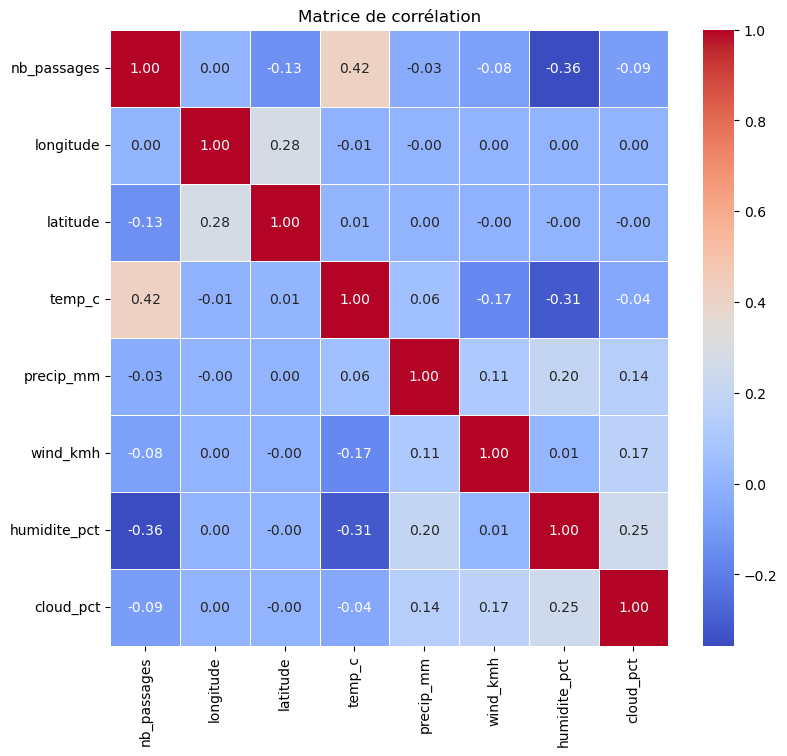

In [58]:
import matplotlib.pyplot as plt
  
df_1 = df.select_dtypes(include=[np.number])
correlation_matrix = df_1.corr()

plt.figure(figsize=(9, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

# ***Drop Collonne***
- ['longitude','latitude']

In [60]:
df = df.drop(columns=['longitude','latitude'])
df.head(5)

,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
0,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
1,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
2,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
3,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
4,2025-01-01,00:00:00,2.0,0.9,0.0,10.4,88.0,98.0


In [61]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000



# ***1 - transformation date en :*** 
#     - ***Jour Semaine***
#     - ***Mois***
--------------------------------------------------------------------------------------

# ***2 - transformation Heure  en :***
#     - ***Minutes*** : [00:00 = 0 , 00:15 = 15 , 07:45 = 465 , 17:00=1020 ]

In [63]:
##### from datetime import datetime

#df_final_v1 = datetime.strptime(df_final_v0['date'] , "%Y-%m-%d")
df['date']         = pd.to_datetime(df['date'])
df["jour_semaine"] = df["date"].dt.dayofweek
df["mois"]         = df["date"].dt.month
df['heure']        = pd.to_timedelta(df['heure'])
df['minutes']      = df['heure'].dt.total_seconds()/60 #).astype(int)
df['hh_mm']        = df['minutes'].apply(lambda x: f"{x // 60:02.0f}:{x % 60:02.0f}")

df.sample(5)

,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,hh_mm
250398,2025-03-08,0 days 06:00:00,0.0,-9.4,0.0,18.3,73.0,67.0,5,3,360.0,06:00
130209,2025-02-03,0 days 20:45:00,5.0,-0.8,0.0,15.3,91.0,100.0,0,2,1245.0,20:45
647193,2025-06-26,0 days 10:15:00,5.0,17.6,0.0,9.1,50.0,100.0,3,6,615.0,10:15
191436,2025-02-20,0 days 01:30:00,0.0,-15.6,0.0,11.2,78.0,5.0,3,2,90.0,01:30
652261,2025-06-27,0 days 20:30:00,19.0,19.1,2.0,15.5,76.0,100.0,4,6,1230.0,20:30


### ***Drope colonnes ['hh_mm','date','heure']***

In [65]:
df = df.drop(columns=['hh_mm','date','heure'])
df.head(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes
0,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0
1,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0
2,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0
3,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0


###### --------------------------------------------------------------------------------------

# **Création des periode de temps pour controler les moments d'achalendage**
# - ***00:00 - 07:00 ----------> minutes entre ( 0000  - 420  ) ----------> : 1***
# - ***07:00 - 09:30 ----------> minutes entre ( 0420  - 570  ) ----------> : 2***
# - ***09:30 - 11:30 ----------> minutes entre ( 0570  - 690  ) ----------> : 3***
# - ***11:30 - 13:30 ----------> minutes entre ( 0690  - 810  ) ----------> : 4***
# - ***13:30 - 16:30 ----------> minutes entre ( 0810  - 990  ) ----------> : 5***
# - ***16:30 - 18:00 ----------> minutes entre ( 0990  - 1080 ) ----------> : 6***
# - ***18:00 - 21:00 ----------> minutes entre ( 1080  - 1260 ) ----------> : 7***
# - ***21:00 - 23:59 ----------> minutes entre ( 1260  - 1439 ) ----------> : 8***
 
--------------------------------------------------------------------------------------    


In [67]:
# Les bornes des intervalles
#ornes = [0,420,570,690,810,990,1080,1260]



conditions = [
    (df['minutes'] >= 0  )   & (df['minutes'] < 420  ),
    (df['minutes'] >= 420 )  & (df['minutes'] < 570  ),
    (df['minutes'] >= 570 )  & (df['minutes'] < 690  ),
    (df['minutes'] >= 690 )  & (df['minutes'] < 810  ),
    (df['minutes'] >= 810 )  & (df['minutes'] < 990  ),
    (df['minutes'] >= 990 )  & (df['minutes'] < 1080 ),
    (df['minutes'] >= 1080 ) & (df['minutes'] < 1260 ),
    (df['minutes'] >= 1260 )
]

# Les codes associés (même longueur que nb d'intervalles)
Codes  = [1,2,3,4,5,6,7,8]

df['periode_code'] = np.select(conditions, Codes, default=0)  # 0 si < 10

df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
530074,3.0,7.1,0.0,6.0,87.0,100.0,5,5,495.0,2
106089,3.0,-15.7,0.0,17.7,66.0,100.0,1,1,840.0,5
509263,46.0,15.7,0.0,12.7,72.0,100.0,6,5,690.0,4
719222,9.0,25.7,0.0,8.2,62.0,21.0,2,7,555.0,2
46363,0.0,-7.5,0.0,0.8,86.0,100.0,0,1,45.0,1
177400,0.0,-10.9,0.0,21.6,80.0,100.0,6,2,450.0,2
327031,2.0,-6.7,0.0,16.8,77.0,100.0,5,3,435.0,2
160842,2.0,-11.6,0.0,11.3,63.0,17.0,1,2,1290.0,8
209512,0.0,4.2,0.0,19.4,69.0,97.0,0,2,1350.0,8
36453,3.0,-10.4,0.0,17.2,79.0,7.0,4,1,645.0,3


In [68]:
# Exporter vers un csv
#-------------------------------------
df.to_csv('Trafic_velo.csv', index=False)